Tested with:
- Python 3.13.9
- numpy 2.4.4
- pandas 2.3.3
- scikit-learn 1.7.2
- modAL 0.4.2.1
- schnetpack 2.2.0
- ase 3.26.0

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pprint  # Pretty print data structures
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import modAL
from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors, MACCSkeys, rdMolDescriptors, rdFingerprintGenerator
from rdkit.ML.Descriptors import MoleculeDescriptors
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error
from sklearn.model_selection import KFold, cross_val_score, cross_validate
from sklearn.model_selection import learning_curve
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.base import clone
plt.style.use('ggplot')  # Set Matplotlib style to 'ggplot'

# ── CONFIG ────────────────────────────────────────────────────────────────────
CSV_PATH = 'data/qm_ext_plus.csv'
SMILES_COL = 'smiles'
TARGET_COL = 'gap'
MORGAN_RADIUS = 2
MORGAN_BITS = 2048

# Do NOT include 'homo' or 'lumo' here — gap = lumo - homo (leakage!)
# Do NOT include thermodynamic properties u0, u298, h298, g298, if one of them is target
BLACKLIST_COLS = [SMILES_COL, TARGET_COL, 'Unnamed: 0', 'mol', 'lumo', 'homo']


# ── FEATURE BUILDERS ─────────────────────────────────────────────────────────
gen = rdFingerprintGenerator.GetMorganGenerator(radius=MORGAN_RADIUS, fpSize=MORGAN_BITS) #create Morgan generator
def morgan_fp(mol):
    '''
    Get Morgan Fingerprints
    '''
    fp = gen.GetFingerprintAsNumPy(mol)
    return np.array(fp, dtype=np.float32)

def maccs_fp(mol):
    '''
    Get 166 public MACCS Keys
    '''
    return np.array(MACCSkeys.GenMACCSKeys(mol), dtype=np.float32)

_rdkit_desc_calc = MoleculeDescriptors.MolecularDescriptorCalculator([d[0] for d in Descriptors.descList])
def rdkit_descs(mol):
    '''
    Get rdkit Molecular descriptors
    '''
    return np.array(_rdkit_desc_calc.CalcDescriptors(mol), dtype=np.float32)

def plot_prediction(X, y, model, name=TARGET_COL, figsize: tuple[int, int] = (10, 6)):
    '''
    Plot predictions for the given model and data.

    Parameters:
    X : Input features.
    y : Actual target values.
    model: Fitted model.
    name: name of the target value
    '''
    y_pred = model.predict(X)
    fig, ax = plt.subplots(figsize=figsize)
    ax.scatter(y, y_pred, c=y, cmap='viridis')
    ax.plot(y, y, 'r-')
    ax.set_xlabel(f'true {name}')
    ax.set_ylabel(f'predicted {name}')
    ax.set_title(f'{name} {model.__class__.__name__} prediction plot')
    plt.show()
    print('Training scores:')
    print (f'MAE = {mean_absolute_error(y,y_pred):.3f}')
    print(f'RMSE = {root_mean_squared_error(y,y_pred):.3f}')
    print(f'r^2 = {r2_score(y,y_pred):.3f}')

def print_cross_val(X, y, model, splits=5, random_state=42):
    '''
    Print cross validation scores for the given model and data.

    Parameters:
    X : Input features.
    y : Actual target values.
    model: Fitted model.
    n_splits: number of cv splits.
    random_state: random state.
    '''
    n_cont = len(qm9_features) + len(rdkit_features)
    preprocessor = ColumnTransformer([
        ('scaler',       StandardScaler(), list(range(n_cont))),
        ('fingerprints', 'passthrough',    list(range(n_cont, X.shape[1]))),
    ])

    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model),
    ])

    cv = KFold(n_splits=splits, shuffle=True, random_state=random_state)
    scoring_metrics = {
        'mae':  'neg_mean_absolute_error',
        'rmse': 'neg_root_mean_squared_error',
        'r2':   'r2',
    }
    results = cross_validate(pipe, X, y, cv=cv, scoring=scoring_metrics)

    print('Cross-validation scores:')
    print(f'Mean MAE  = {np.mean(np.abs(results['test_mae'])):.3f}')
    print(f'Mean RMSE = {np.mean(np.abs(results['test_rmse'])):.3f}')
    print(f'Mean R²   = {np.mean(results['test_r2']):.3f}')

def plot_violin(X, y, models, metric='rmse', target_name=TARGET_COL, splits=5, y_min=0, y_max=None, figsize: tuple[int, int] = (10, 6)):
    '''
    Plot RMSE violin plot for given models and data.

    Parameters:
    X           : Raw input features.
    y           : Target values (np.array).
    models      : List of unfitted model instances.
    target_name : Label for plot title.
    splits      : Number of CV splits.
    y_min       : Y-axis min value.
    y_max       : Y-axis max value.
    metric      : 'rsr' or 'rmse'
    '''
    n_cont = len(qm9_features) + len(rdkit_features)
    preprocessor = ColumnTransformer([
        ('scaler',       StandardScaler(), list(range(n_cont))),
        ('fingerprints', 'passthrough',    list(range(n_cont, X.shape[1]))),
    ])

    records = []
    for model in models:
        pipe = Pipeline([
            ('preprocessor', preprocessor),
            ('model', model),
        ])
        scores = cross_val_score(
            estimator=pipe,
            X=X,
            y=y,
            cv=splits,
            scoring='neg_root_mean_squared_error',
            n_jobs=-1,
        )
        if metric == 'rmse':
            for score in scores:
                records.append({'Model': model.__class__.__name__, 'RMSE': -score})
        else:
            for score in scores:
                records.append({'Model': model.__class__.__name__, 'RSR': -score/y.std()})
                
    df_plot = pd.dataFrame(records)

    fig, ax = plt.subplots(figsize=figsize)
    sns.violinplot(
        data=df_plot,
        y='RMSE' if metric == 'rmse' else 'RSR',
        x='Model',
        hue='Model',
        inner='quartile',
        legend=False,
        ax=ax,
    )
    ax.set_title(f'{target_name}\nModel Comparison — CV RMSE Scores' if metric == 'rmse' else f'{target_name}\nModel Comparison — CV RSR Scores')
    ax.set_ylim(y_min, y_max)
    ax.grid(True, linestyle='-', alpha=0.5)
    plt.tight_layout()
    plt.show()

def plot_feature_importances(
    model,
    qm9_features: list[str],
    rdkit_features: list[str],
    top_n: int = 20,
    morgan_bits: int = 2048,
    maccs_bits: int = 167,
    figsize: tuple[int, int] = (10, 6),
):
    '''
    Plot top-N aggregated feature importances for an RF trained on:
    [QM9 | RDKit descriptors | Morgan FP (aggregated) | MACCS keys (aggregated)]

    Matches build_X column order exactly.

    Parameters:
    model:         Fitted sklearn RF.
    qm9_features:  QM9 feature names (continuous block, first).
    rdkit_features: RDKit descriptor names (continuous block, second).
    top_n:         Features to display.
    morgan_bits:   Morgan FP length (default 2048).
    maccs_bits:    MACCS key length (default 166).
    figsize:       Figure size.

    Returns:
    pd.Series of aggregated importances, sorted descending.
    '''
    feature_names = (
        list(qm9_features)
        + list(rdkit_features)
        + ['Morgan_FP'] * morgan_bits
        + ['MACCS_Keys'] * maccs_bits
    )

    importances = model.feature_importances_

    if len(importances) != len(feature_names):
        raise ValueError(
            f'Feature count mismatch: model has {len(importances)}, '
            f'expected {len(feature_names)} '
            f'({len(qm9_features)} QM9 + {len(rdkit_features)} RDKit '
            f'+ {morgan_bits} Morgan + {maccs_bits} MACCS).'
        )

    agg: pd.Series = (
        pd.Series(importances, index=feature_names)
        .groupby(level=0)
        .sum()
        .sort_values(ascending=False)
    )

    top = agg.head(top_n)

    fig, ax = plt.subplots(figsize=figsize)
    top.iloc[::-1].plot.barh(ax=ax, color='steelblue', edgecolor='white')
    ax.set_xlabel('Summed Feature Importance')
    ax.set_title(f'Top {top_n} Feature Importances')
    ax.tick_params(axis='y', labelsize=9)
    ax.grid(axis='x', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    return agg

def plot_learning_curve(X_train, y_train, X_test, y_test, model, metric='r2', random_state=4, figsize: tuple[int, int] = (10, 6)):
    '''
    Plot learning curve: train model on 10%→100% of X_train, score on X_test.

    Parameters:
    metric: 'r2' or 'rmse'
    '''
    train_sizes = np.linspace(0.1, 1.0, 10)
    n_total     = len(X_train)
    scores      = []

    for size in train_sizes:
        n   = max(1, int(size * n_total))
        idx = np.random.default_rng(random_state).choice(n_total, n, replace=False)
        model.fit(X_train[idx], y_train[idx])

        if metric == 'r2':
            scores.append(r2_score(y_test, model.predict(X_test)))
        else:
            scores.append(root_mean_squared_error(y_test, model.predict(X_test)))

    plt.figure(figsize=figsize)
    plt.plot(train_sizes * 100, scores, marker='o')
    plt.xlim(0, 110)
    plt.ylim(0, 1) if metric == 'r2' else plt.ylim(0, None)
    plt.xlabel('Training set size (%)')
    plt.ylabel('R²' if metric == 'r2' else 'RMSE')
    plt.title(f'Learning Curve — {'R²' if metric == 'r2' else 'RMSE'}')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [ ]:
# 95% OOD split (HOMO-LUMO gap)
df = pd.read_csv('data/qm9_full.csv')
df = df.drop(columns=['Unnamed: 0'])

threshold = df['gap'].quantile(0.95)
print(f'Threshold for OOD (95th percentile): {threshold:.4f}')

ood_df = df[df['gap'] >= threshold].copy()

id_df = df[df['gap'] < threshold].copy()

# 1. Split 80% train, 20% temp
strat_bins = pd.qcut(id_df['gap'], q=10, labels=False)
id_df_train, id_df_temp = train_test_split(id_df, test_size=0.2, stratify=strat_bins, random_state=42)

# 2. Split temp 50/50 to get 10% test, 10% val
temp_bins = pd.qcut(id_df_temp['gap'], q=10, labels=False)
id_df_test, id_df_val = train_test_split(id_df_temp, test_size=0.5, random_state=42, stratify=temp_bins)

# 3. Save to disk
ood_df.to_csv('data/qm9_ood_gap.csv', index=False)
id_df_train.to_csv('data/qm9_id_gap_train.csv', index=False)
id_df_test.to_csv('data/qm9_id_gap_test.csv', index=False)
id_df_val.to_csv('data/qm9_id_gap_val.csv', index=False)

In [2]:
# Load Sample OOD
df_train = pd.read_csv('data/ood/qm9_id_gap_train.csv')
bins_train = pd.qcut(df_train['gap'], q=10, labels=False)
_, df_train = train_test_split(df_train, test_size=0.02, stratify=bins_train, random_state=42)

df_test = pd.read_csv('data/ood/qm9_id_gap_test.csv')
bins_test = pd.qcut(df_test['gap'], q=10, labels=False)
_, df_test = train_test_split(df_test, test_size=0.02, stratify=bins_test, random_state=42)

df_val = pd.read_csv('data/ood/qm9_id_gap_val.csv')
bins_val = pd.qcut(df_val['gap'], q=10, labels=False)
_, df_val = train_test_split(df_val, test_size=0.02, stratify=bins_val, random_state=42)

df_ood = pd.read_csv('data/ood/qm9_ood_gap.csv')
bins_ood = pd.qcut(df_ood['gap'], q=10, labels=False)
_, df_ood = train_test_split(df_ood, test_size=0.04, stratify=bins_ood, random_state=42)


rdkit_features = [d[0] for d in Descriptors.descList]
qm9_features = [c for c in list(df_train.columns) if c not in BLACKLIST_COLS and c not in rdkit_features]

def build_X(df, scaler = StandardScaler(), train=False, raw=False):
    '''
    Build X with scaled continuous part and fingerprints.
    If raw=True, returns unscaled X (for use in CV pipeline).
    '''
    df = df.copy()
    df['mol'] = df['smiles'].apply(Chem.MolFromSmiles)
    morgan     = np.stack(df['mol'].apply(morgan_fp).values)
    maccs      = np.stack(df['mol'].apply(maccs_fp).values)
    continuous = np.hstack([df[qm9_features].values, df[rdkit_features].values])

    if raw:
        return np.hstack([continuous, morgan, maccs])

    continuous = scaler.fit_transform(continuous) if train else scaler.transform(continuous)
    return np.hstack([continuous, morgan, maccs])
    
X_train = build_X(df_train, train=True)
X_test = build_X(df_test)
X_val = build_X(df_val)
X_ood = build_X(df_ood)

y_train = df_train[TARGET_COL].values
y_test = df_test[TARGET_COL].values
y_val = df_val[TARGET_COL].values
y_ood = df_ood[TARGET_COL].values

print(f'Train set Molecules: {X_train.shape[0]}  |  Features: {X_train.shape[1]}')
print(f'Test set Molecules: {X_test.shape[0]}  |  Features: {X_test.shape[1]}')
print(f'Validate set Molecules: {X_val.shape[0]}  |  Features: {X_val.shape[1]}')
print(f'OOD set Molecules: {X_ood.shape[0]}  |  Features: {X_ood.shape[1]}')

Train set Molecules: 2394  |  Features: 2441
Test set Molecules: 300  |  Features: 2441
Validate set Molecules: 300  |  Features: 2441
OOD set Molecules: 316  |  Features: 2441


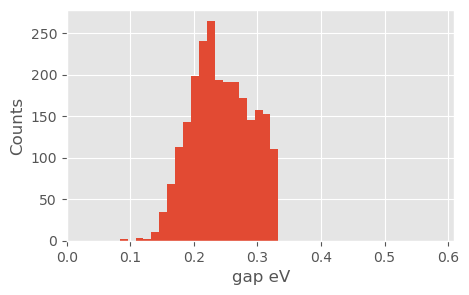

In [122]:
# Plot a histogram
plt.figure(figsize=(5,3))
plt.hist(df_train['gap'], bins=20)
plt.xlabel(r'gap Ha')
plt.ylabel('Counts')
plt.xlim(0, 0.61)
plt.show()

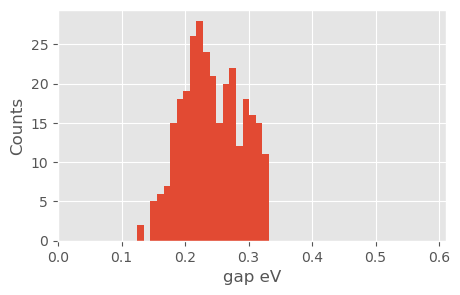

In [120]:
# Plot a histogram
plt.figure(figsize=(5,3))
plt.hist(df_test['gap'], bins=20)
plt.xlabel(r'gap Ha')
plt.ylabel('Counts')
plt.xlim(0, 0.61)
plt.show()

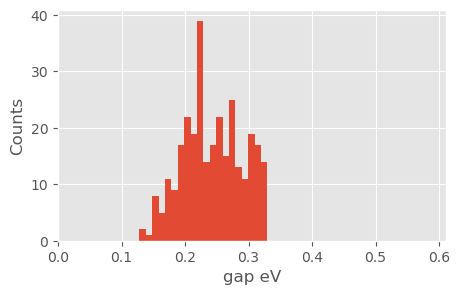

In [121]:
# Plot a histogram
plt.figure(figsize=(5,3))
plt.hist(df_val['gap'], bins=20)
plt.xlabel(r'gap Ha')
plt.ylabel('Counts')
plt.xlim(0, 0.61)
plt.show()

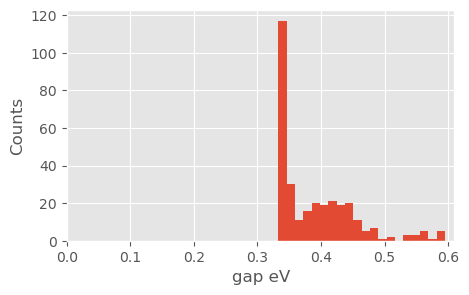

In [123]:
# Plot a histogram
plt.figure(figsize=(5,3))
plt.hist(df_ood['gap'], bins=20)
plt.xlabel(r'gap Ha')
plt.ylabel('Counts')
plt.xlim(0, 0.61)
plt.show()

## Baseline

In [124]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(
    n_estimators=500,
    max_features='sqrt',
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=42,
)
rf.fit(X_train, y_train)

,n_estimators,500
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [125]:
from sklearn.kernel_ridge import KernelRidge
kr = KernelRidge(
    alpha=0.01,
    gamma=0.0001,
    kernel='laplacian',
)
kr.fit(X_train,y_train)

,alpha,0.01
,kernel,'laplacian'
,gamma,0.0001
,degree,3
,coef0,1
,kernel_params,None


In [126]:
from xgboost import XGBRegressor
xgb = XGBRegressor(
    booster='gbtree',
    colsample_bytree=0.6,
    learning_rate=0.1,
    max_depth=4,
    min_child_weight=3,
    n_estimators=100,
    reg_alpha=0.1,
    reg_lambda=1.0,
    subsample=0.8,
)
xgb.fit(X_train,y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,'gbtree'
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.6
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [48]:
from modAL.models import CommitteeRegressor
from modAL.disagreement import max_std_sampling

def committee_model(models, X_train, y_train):
    learner_list = [
        ActiveLearner(
            estimator=clone(model),
            X_training=X_train,
            y_training=y_train,
        )
        for model in models
    ]
    
    committee = CommitteeRegressor(
        learner_list=learner_list,
        query_strategy=max_std_sampling,
    )
    return committee

models = [rf, kr, xgb]

committee = committee_model(models, X_train, y_train)

In [127]:
# Score of the model
rf_score = {
    'train_rmse': root_mean_squared_error(y_train, rf.predict(X_train)),
    'train_r2':  r2_score(y_train,  rf.predict(X_train)),
    'test_rmse': root_mean_squared_error(y_test, rf.predict(X_test)),
    'test_r2':  r2_score(y_test,  rf.predict(X_test)),
    'val_rmse':  root_mean_squared_error(y_val,  rf.predict(X_val)),
    'val_r2':   r2_score(y_val,   rf.predict(X_val)),
}
print(rf_score)

kr_score = {
    'train_rmse': root_mean_squared_error(y_train, kr.predict(X_train)),
    'train_r2':  r2_score(y_train,  kr.predict(X_train)),
    'test_rmse': root_mean_squared_error(y_test, kr.predict(X_test)),
    'test_r2':  r2_score(y_test,  kr.predict(X_test)),
    'val_rmse':  root_mean_squared_error(y_val,  kr.predict(X_val)),
    'val_r2':   r2_score(y_val,   kr.predict(X_val)),
}
print(kr_score)

xgb_score = {
    'train_rmse': root_mean_squared_error(y_train, xgb.predict(X_train)),
    'train_r2':  r2_score(y_train,  xgb.predict(X_train)),
    'test_rmse': root_mean_squared_error(y_test, xgb.predict(X_test)),
    'test_r2':  r2_score(y_test,  xgb.predict(X_test)),
    'val_rmse':  root_mean_squared_error(y_val,  xgb.predict(X_val)),
    'val_r2':   r2_score(y_val,   xgb.predict(X_val)),
}
print(xgb_score)

committee_score = {
    'train_rmse': root_mean_squared_error(y_train, committee.predict(X_train)),
    'train_r2':  r2_score(y_train,  committee.predict(X_train)),
    'test_rmse': root_mean_squared_error(y_test, committee.predict(X_test)),
    'test_r2':  r2_score(y_test,  committee.predict(X_test)),
    'val_rmse':  root_mean_squared_error(y_val,  committee.predict(X_val)),
    'val_r2':   r2_score(y_val,   committee.predict(X_val)),
}
print(committee_score)

{'train_rmse': 0.010255746927999252, 'train_r2': 0.9512046043359935, 'test_rmse': 0.02004656371363824, 'test_r2': 0.8128753873797874, 'val_rmse': 0.019874770170587117, 'val_r2': 0.8200367814406457}
{'train_rmse': 0.010126283784943242, 'train_r2': 0.9524287633950299, 'test_rmse': 0.015388705645355834, 'test_r2': 0.8897305465214697, 'val_rmse': 0.015463510093328595, 'val_r2': 0.8910579143082955}
{'train_rmse': 0.010698411819635188, 'train_r2': 0.9469014238553604, 'test_rmse': 0.015711423019115447, 'test_r2': 0.8850571183798662, 'val_rmse': 0.016076544358431213, 'val_r2': 0.8822489122836299}
{'train_rmse': 0.03799046962209853, 'train_r2': 0.3304337154821161, 'test_rmse': 0.038489525692355364, 'test_r2': 0.31017940617778816, 'val_rmse': 0.03987753920346249, 'val_r2': 0.2755036154085583}


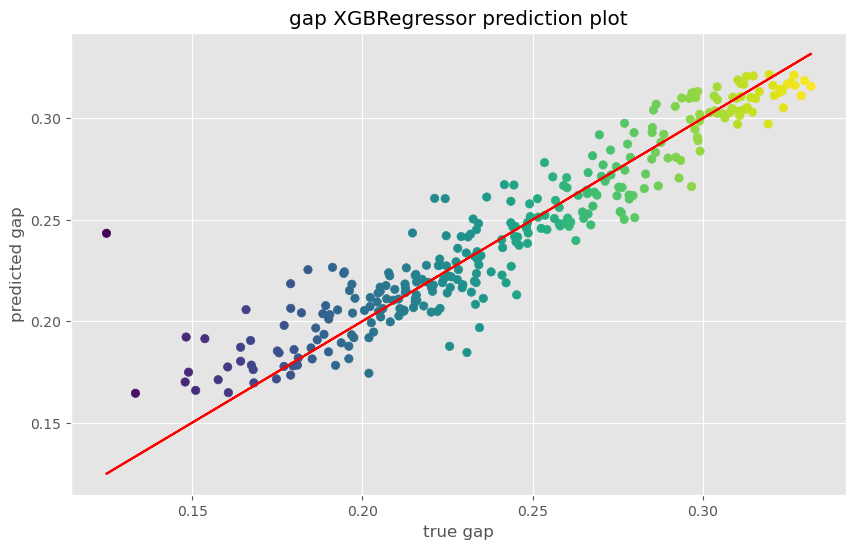

Training scores:
MAE = 0.011
RMSE = 0.016
r^2 = 0.885


In [130]:
plot_prediction(X_test, y_test, xgb)

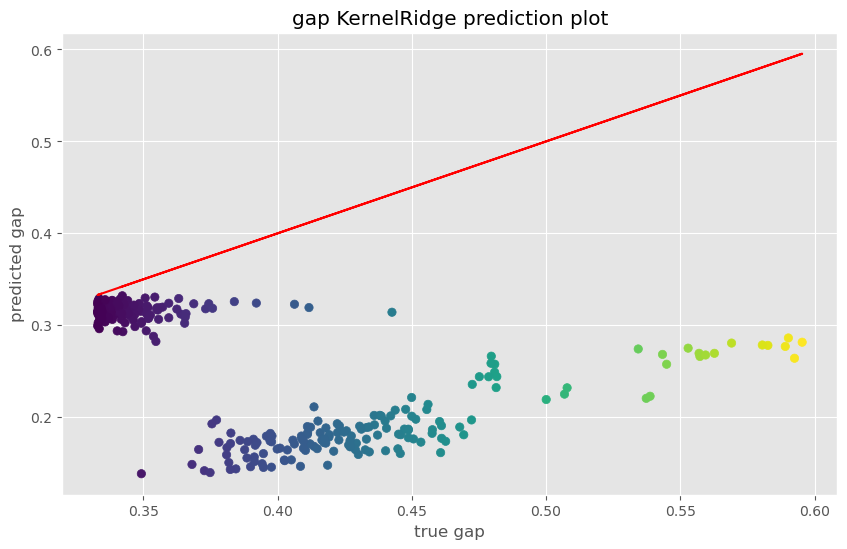

Training scores:
MAE = 0.135
RMSE = 0.176
r^2 = -7.216


In [136]:
plot_prediction(X_ood, y_ood, kr)

In [64]:
print_cross_val(X_cv, y_train, rf)

Cross-validation scores:
Mean MAE  = 0.017
Mean RMSE = 0.024
Mean R²   = 0.822


{'fit_time': array([0.50598025, 0.46400213, 0.52041268, 0.53708076, 0.48586082]),
 'score_time': array([0.14808869, 0.14795494, 0.12902164, 0.08358002, 0.12156057]),
 'test_mae': array([-0.01644799, -0.01607576, -0.01725342, -0.01606048, -0.01750535]),
 'test_rmse': array([-0.02469771, -0.02244883, -0.02539042, -0.0243015 , -0.024934  ]),
 'test_r2': array([0.8154605 , 0.85186539, 0.80695071, 0.83856857, 0.79926018])}

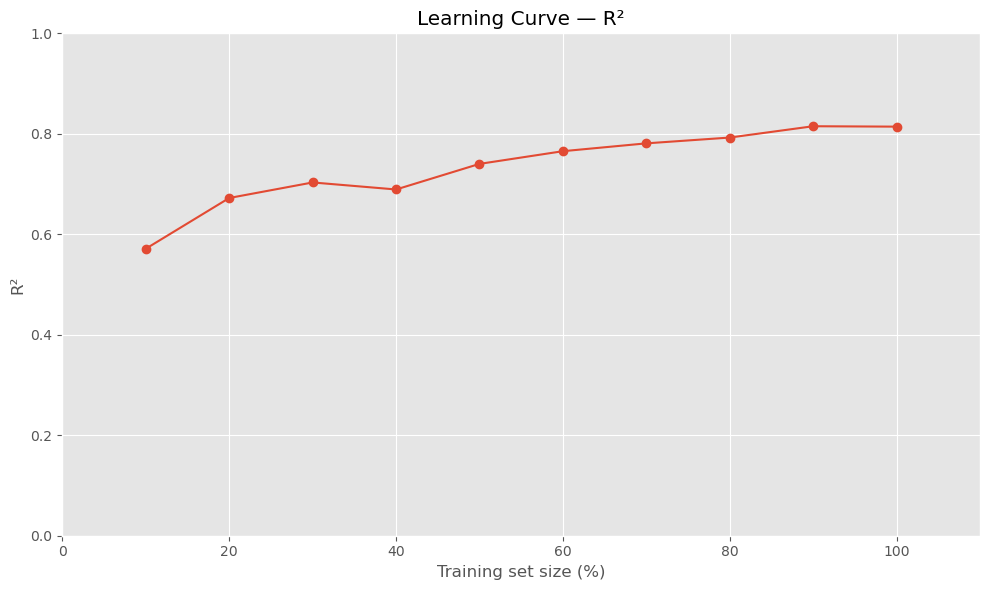

In [87]:
plot_learning_curve(X_train, y_train, X_test, y_test, rf, 'r2')

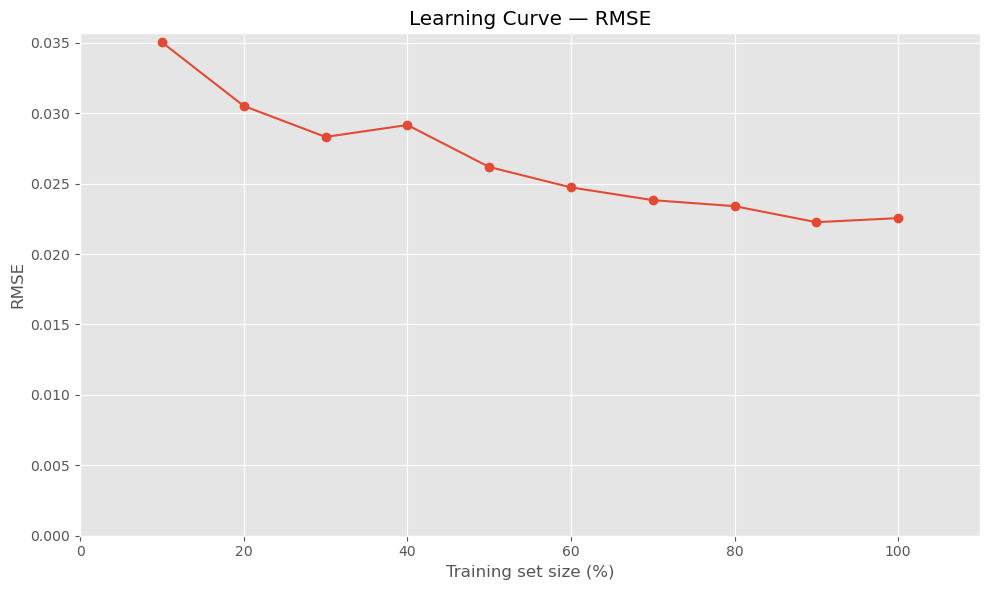

In [11]:
plot_learning_curve(X_train, y_train, X_test, y_test, rf, 'rmse')

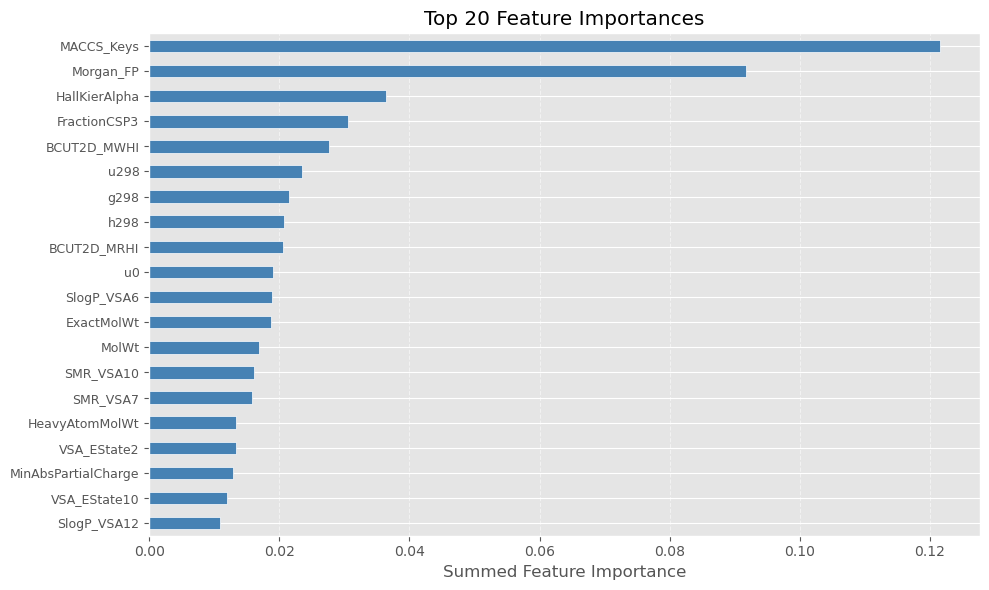

In [5]:
agg = plot_feature_importances(
    model=rf,
    qm9_features=qm9_features,
    rdkit_features=rdkit_features,
    top_n=20,
)

# AL Query strategies

In [29]:
from modAL.models import ActiveLearner

# Config
SEED_SIZE  = 20    # initial labeled samples
BATCH_SIZE = 100    # samples added per AL iteration
N_RUNS = 5

def record(learner: ActiveLearner, history):
    X_lab, y_lab = learner.X_training, learner.y_training
    history['n_labeled'].append(len(X_lab))
    history['train_rmse'].append(root_mean_squared_error(y_lab, learner.predict(X_lab)))
    history['train_r2'].append(r2_score(y_lab, learner.predict(X_lab)))
    history['test_rmse'].append(root_mean_squared_error(y_test, learner.predict(X_test)))
    history['test_r2'].append(r2_score(y_test, learner.predict(X_test)))
    history['val_rmse'].append(root_mean_squared_error(y_val, learner.predict(X_val)))
    history['val_r2'].append(r2_score(y_val, learner.predict(X_val)))

def al_loop(model, query_strat, initial_idx=None):
    if initial_idx is None:
        initial_idx = np.random.default_rng(42).choice(len(X_train), size=SEED_SIZE, replace=False)
    
    pool_mask   = np.ones(len(X_train), dtype=bool) 
    pool_mask[initial_idx] = False # pool mask
    X_seed, y_seed = X_train[initial_idx], y_train[initial_idx]
    X_pool, y_pool = X_train[pool_mask].copy(), y_train[pool_mask].copy()

    model = clone(model)
    
    learner = ActiveLearner(
        estimator=model,
        query_strategy=query_strat,
        X_training=X_seed,
        y_training=y_seed,
    )
    
    history = {
        'n_labeled': [],
        'train_rmse': [],
        'train_r2': [],
        'test_rmse':  [],
        'test_r2':  [],
        'val_rmse':   [],
        'val_r2':   [],
    }
    
    n_queries = len(X_pool) // BATCH_SIZE

    record(learner, history)
    
    print(f'{'iter':>4} | {'labeled':>5} | {'test_RMSE':>9} | {'val_RMSE':>8}')
    print(
        f'{0:>4d} | {history['n_labeled'][-1]:>7d} | '
        f'{history['test_rmse'][-1]:9.4f} | '
        f'{history['val_rmse'][-1]:8.4f}'
        )
    
    for i in range(n_queries):
        if len(X_pool) == 0:
            break
    
        n_instances = min(BATCH_SIZE, len(X_pool))
        
        query_idx, _ = learner.query(X_pool, n_instances=n_instances)
        learner.teach(X_pool[query_idx], y_pool[query_idx])        
        
        # remove queried samples from pool
        X_pool = np.delete(X_pool, query_idx, axis=0)
        y_pool = np.delete(y_pool, query_idx, axis=0)
    
        record(learner, history)
    
        print(
            f'{i+1:>4d} | {history['n_labeled'][-1]:>7d} | '
            f'{history['test_rmse'][-1]:9.4f} | '
            f'{history['val_rmse'][-1]:8.4f}'
            )
    return history

def mult_al(model, query_strat, n_runs=N_RUNS, qbc=False):
    all_histories = []

    for run in range(n_runs):
        initial_idx = np.random.default_rng(run).choice(len(X_train), size=SEED_SIZE, replace=False)

        print(f'\n RUN {run+1}/{n_runs}')

        if qbc:
            history = al_loop_qbc(model, query_strat, initial_idx)
        else:
            history = al_loop(model, query_strat, initial_idx)

        all_histories.append(
            {'run': run,
            'initial_idx': initial_idx,
            'history': history,
            })
    return all_histories

## Random Sampling

In [6]:
def rf_random_query(regressor, X_pool, n_instances=1, **kwargs):
    query_idx = np.random.choice(
        range(len(X_pool)), size=n_instances, replace=False
    )
    return query_idx, X_pool[query_idx]

In [31]:
history_rnd = mult_al(rf, rf_random_query)


 RUN 1/5
iter | labeled | test_RMSE | val_RMSE
   0 |      20 |    0.0507 |   0.0555
   1 |     120 |    0.0413 |   0.0455
   2 |     220 |    0.0381 |   0.0417
   3 |     320 |    0.0358 |   0.0394
   4 |     420 |    0.0352 |   0.0374
   5 |     520 |    0.0329 |   0.0358
   6 |     620 |    0.0298 |   0.0322
   7 |     720 |    0.0293 |   0.0314
   8 |     820 |    0.0294 |   0.0311
   9 |     920 |    0.0287 |   0.0293
  10 |    1020 |    0.0276 |   0.0279
  11 |    1120 |    0.0265 |   0.0274
  12 |    1220 |    0.0261 |   0.0277
  13 |    1320 |    0.0256 |   0.0271
  14 |    1420 |    0.0257 |   0.0266
  15 |    1520 |    0.0257 |   0.0265
  16 |    1620 |    0.0254 |   0.0257
  17 |    1720 |    0.0250 |   0.0255
  18 |    1820 |    0.0250 |   0.0253
  19 |    1920 |    0.0250 |   0.0251
  20 |    2020 |    0.0251 |   0.0249
  21 |    2120 |    0.0247 |   0.0247
  22 |    2220 |    0.0245 |   0.0250
  23 |    2320 |    0.0247 |   0.0240
  24 |    2420 |    0.0246 |   0.0242
  

## Uncertainty Sampling

In [7]:
# Custom uncertainty query strategy for regression
def rf_uncertainty_query(regressor, X_pool, n_instances=1, **kwargs):
    tree_preds = np.array(
        [tree.predict(X_pool) for tree in regressor.estimator.estimators_]
    )
    uncertainty = np.std(tree_preds, axis=0)
    query_idx   = np.argsort(uncertainty)[-n_instances:]  # highest uncertainty first
    return query_idx, X_pool[query_idx]

In [32]:
history_unc = mult_al(rf, rf_uncertainty_query)


 RUN 1/5
iter | labeled | test_RMSE | val_RMSE
   0 |      20 |    0.0507 |   0.0555
   1 |     120 |    0.0430 |   0.0456
   2 |     220 |    0.0377 |   0.0354
   3 |     320 |    0.0340 |   0.0318
   4 |     420 |    0.0310 |   0.0296
   5 |     520 |    0.0294 |   0.0279
   6 |     620 |    0.0285 |   0.0274
   7 |     720 |    0.0280 |   0.0269
   8 |     820 |    0.0274 |   0.0264
   9 |     920 |    0.0274 |   0.0264
  10 |    1020 |    0.0269 |   0.0260
  11 |    1120 |    0.0264 |   0.0257
  12 |    1220 |    0.0260 |   0.0253
  13 |    1320 |    0.0257 |   0.0250
  14 |    1420 |    0.0257 |   0.0249
  15 |    1520 |    0.0253 |   0.0246
  16 |    1620 |    0.0252 |   0.0246
  17 |    1720 |    0.0250 |   0.0244
  18 |    1820 |    0.0245 |   0.0239
  19 |    1920 |    0.0246 |   0.0237
  20 |    2020 |    0.0246 |   0.0241
  21 |    2120 |    0.0245 |   0.0238
  22 |    2220 |    0.0240 |   0.0241
  23 |    2320 |    0.0243 |   0.0238
  24 |    2420 |    0.0242 |   0.0238
  

## Diversity based sampling

### Tanimoto similarity

In [9]:
def tanimoto_diversity_query(learner, X_pool, n_instances=1, **kwargs):
    '''
    Greedy diversity sampling using max-min Tanimoto on fingerprint columns.
    '''
    
    fp_slice = slice(len(qm9_features)+len(rdkit_features), None) # Get slice with Fingerprints only (Morgan + MACCSkeys) 

    def max_tanimoto(A, B):
        A = (A > 0).astype(np.int32, copy=False)
        B = (B > 0).astype(np.int32, copy=False)

        inter = A @ B.T
        union = (
            A.sum(axis=1)[:, None] + B.sum(axis=1)[None, :] - inter
        )
        sim = np.divide(
            inter,
            union,
            out=np.ones_like(inter, dtype=float),
            where=union != 0,
        )
        return sim.max(axis=1)

    X_pool = np.asarray(X_pool)
    X_pool_fp = X_pool[:, fp_slice]

    X_train = np.asarray(learner.X_training)
    X_train_fp = X_train[:, fp_slice]

    if len(X_train_fp) > 0:
        max_sim = max_tanimoto(X_pool_fp, X_train_fp)
    else:
        max_sim = np.zeros(len(X_pool_fp), dtype=float)

    selected = []
    n_instances = min(n_instances, len(X_pool))

    for _ in range(n_instances):
        if selected:
            sim_to_last = max_tanimoto(
                X_pool_fp, X_pool_fp[[selected[-1]]]
            )
            max_sim = np.maximum(max_sim, sim_to_last)

        if selected:
            max_sim[selected] = np.inf

        next_idx = np.argmin(max_sim)
        selected.append(next_idx)

    query_idx = np.array(selected, dtype=int)
    return query_idx, X_pool[query_idx]

In [35]:
history_tan = mult_al(rf, tanimoto_diversity_query)


 RUN 1/5
iter | labeled | test_RMSE | val_RMSE
   0 |      20 |    0.0507 |   0.0555
   1 |     120 |    0.0384 |   0.0383
   2 |     220 |    0.0355 |   0.0351
   3 |     320 |    0.0347 |   0.0330
   4 |     420 |    0.0348 |   0.0322
   5 |     520 |    0.0343 |   0.0309
   6 |     620 |    0.0329 |   0.0297
   7 |     720 |    0.0312 |   0.0289
   8 |     820 |    0.0298 |   0.0284
   9 |     920 |    0.0302 |   0.0278
  10 |    1020 |    0.0298 |   0.0276
  11 |    1120 |    0.0296 |   0.0270
  12 |    1220 |    0.0276 |   0.0263
  13 |    1320 |    0.0276 |   0.0262
  14 |    1420 |    0.0273 |   0.0262
  15 |    1520 |    0.0272 |   0.0259
  16 |    1620 |    0.0270 |   0.0257
  17 |    1720 |    0.0269 |   0.0255
  18 |    1820 |    0.0257 |   0.0250
  19 |    1920 |    0.0252 |   0.0253
  20 |    2020 |    0.0255 |   0.0252
  21 |    2120 |    0.0248 |   0.0250
  22 |    2220 |    0.0252 |   0.0247
  23 |    2320 |    0.0245 |   0.0246
  24 |    2420 |    0.0246 |   0.0241
  

## QBC

In [12]:
from modAL.models import CommitteeRegressor
from modAL.disagreement import max_std_sampling

def record_qbc(model, X_lab, y_lab, history):
    y_pred_lab = model.predict(X_lab)
    y_pred_test = model.predict(X_test)
    y_pred_val = model.predict(X_val)

    history['n_labeled'].append(len(X_lab))
    history['train_rmse'].append(root_mean_squared_error(y_lab, y_pred_lab))
    history['train_r2'].append(r2_score(y_lab, y_pred_lab))
    history['test_rmse'].append(root_mean_squared_error(y_test, y_pred_test))
    history['test_r2'].append(r2_score(y_test, y_pred_test))
    history['val_rmse'].append(root_mean_squared_error(y_val, y_pred_val))
    history['val_r2'].append(r2_score(y_val, y_pred_val))


def al_loop_qbc(models, query_strat=max_std_sampling, initial_idx=None,):
    if initial_idx is None:
        initial_idx = np.random.default_rng(42).choice(len(X_train), size=SEED_SIZE, replace=False)
    
    pool_mask = np.ones(len(X_train), dtype=bool)
    pool_mask[initial_idx] = False

    X_seed, y_seed = X_train[initial_idx], y_train[initial_idx]
    X_pool, y_pool = X_train[pool_mask].copy(), y_train[pool_mask].copy()

    # track the full labeled set manually
    X_lab, y_lab = X_seed.copy(), y_seed.copy()

    # one learner per model
    learner_list = [
        ActiveLearner(
            estimator=clone(model),
            X_training=X_seed,
            y_training=y_seed,
        )
        for model in models
    ]

    committee = CommitteeRegressor(
        learner_list=learner_list,
        query_strategy=query_strat,
    )

    history = {
        'n_labeled': [],
        'train_rmse': [],
        'train_r2': [],
        'test_rmse': [],
        'test_r2': [],
        'val_rmse': [],
        'val_r2': [],
    }

    record_qbc(committee, X_lab, y_lab, history)

    print(f'{'iter':>4} | {'labeled':>7} | {'test_RMSE':>9} | {'val_RMSE':>8}')
    print(
        f'{0:>4d} | {history['n_labeled'][-1]:>7d} | '
        f'{history['test_rmse'][-1]:9.4f} | '
        f'{history['val_rmse'][-1]:8.4f}'
    )

    n_queries = len(X_pool) // BATCH_SIZE

    for i in range(n_queries):
        if len(X_pool) == 0:
            break

        n_instances = min(BATCH_SIZE, len(X_pool))

        query_idx, _ = committee.query(X_pool, n_instances=n_instances)

        X_new = X_pool[query_idx]
        y_new = y_pool[query_idx]

        committee.teach(X_new, y_new)

        X_lab = np.vstack([X_lab, X_new])
        y_lab = np.concatenate([y_lab, y_new])

        X_pool = np.delete(X_pool, query_idx, axis=0)
        y_pool = np.delete(y_pool, query_idx, axis=0)

        record_qbc(committee, X_lab, y_lab, history)

        print(
            f'{i+1:>4d} | {history['n_labeled'][-1]:>7d} | '
            f'{history['test_rmse'][-1]:9.4f} | '
            f'{history['val_rmse'][-1]:8.4f}'
        )

    return history

In [36]:
models = [rf, kr, xgb]
history_qbc = mult_al(models, max_std_sampling, qbc=True)


 RUN 1/5
iter | labeled | test_RMSE | val_RMSE
   0 |      20 |    0.0496 |   0.0542
   1 |     120 |    0.0382 |   0.0371
   2 |     220 |    0.0349 |   0.0319
   3 |     320 |    0.0316 |   0.0296
   4 |     420 |    0.0279 |   0.0270
   5 |     520 |    0.0261 |   0.0246
   6 |     620 |    0.0253 |   0.0235
   7 |     720 |    0.0242 |   0.0226
   8 |     820 |    0.0235 |   0.0222
   9 |     920 |    0.0229 |   0.0218
  10 |    1020 |    0.0231 |   0.0216
  11 |    1120 |    0.0216 |   0.0213
  12 |    1220 |    0.0216 |   0.0213
  13 |    1320 |    0.0214 |   0.0210
  14 |    1420 |    0.0213 |   0.0209
  15 |    1520 |    0.0206 |   0.0205
  16 |    1620 |    0.0204 |   0.0200
  17 |    1720 |    0.0205 |   0.0204
  18 |    1820 |    0.0207 |   0.0200
  19 |    1920 |    0.0203 |   0.0200
  20 |    2020 |    0.0199 |   0.0198
  21 |    2120 |    0.0204 |   0.0202
  22 |    2220 |    0.0201 |   0.0200
  23 |    2320 |    0.0201 |   0.0200
  24 |    2420 |    0.0204 |   0.0199
  

# Results

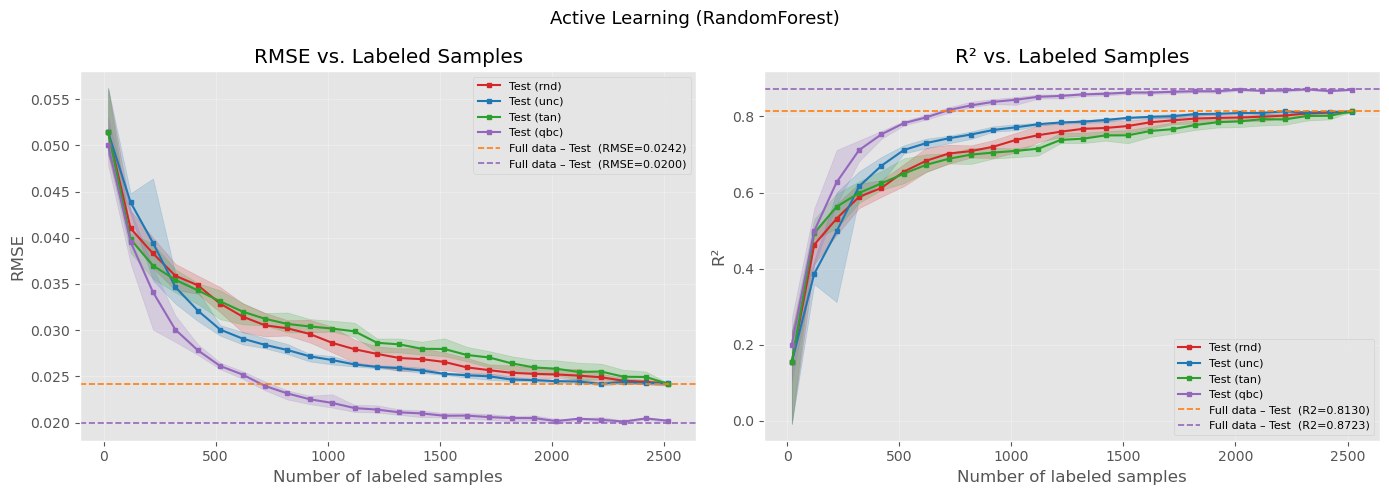

In [89]:
plt_train = False
plt_test = True
plt_val = False

# ── visualisation ─────────────────────────────────────────────────────────────
n = np.array(history_rnd[0]['history']['n_labeled'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Active Learning (RandomForest)', fontsize=13)

# --- RMSE ---
ax = axes[0]
# ax.set_xscale('log')
if plt_train:
    ax.plot(n, history_rnd['train_rmse'], 'o-',  ms=3, lw=1.5, label='Train (rnd)', color='tab:red',)
    ax.plot(n, history_unc['train_rmse'], 'o-.',  ms=3, lw=1.5, label='Train (unc)', color='tab:red',)
    ax.plot(n, history_tan['train_rmse'], 'o:',  ms=3, lw=1.5, label='Train (tan)', color='tab:red',)
    ax.axhline(rf_score['train_rmse'],  color='tab:red',  ls='--', lw=1.2,
               label=f'Full data – Train   (RMSE={rf_score['train_rmse']:.4f})')

if plt_test:
    y_rnd = np.array([run['history']['test_rmse'] for run in history_rnd], dtype=float)
    ax.plot(n, y_rnd.mean(axis=0),  's-',  ms=3, lw=1.5, label='Test (rnd)', color='tab:red', )
    ax.fill_between(n, y_rnd.min(axis=0), y_rnd.max(axis=0), color='tab:red', alpha=0.2,)

    y_unc = np.array([run['history']['test_rmse'] for run in history_unc], dtype=float)
    ax.plot(n, y_unc.mean(axis=0),  's-',  ms=3, lw=1.5, label='Test (unc)', color='tab:blue', )
    ax.fill_between(n, y_unc.min(axis=0), y_unc.max(axis=0), color='tab:blue', alpha=0.2,)

    y_tan = np.array([run['history']['test_rmse'] for run in history_tan], dtype=float)
    ax.plot(n, y_tan.mean(axis=0),  's-',  ms=3, lw=1.5, label='Test (tan)', color='tab:green', )
    ax.fill_between(n, y_tan.min(axis=0), y_tan.max(axis=0), color='tab:green', alpha=0.2,)

    y_qbc = np.array([run['history']['test_rmse'] for run in history_qbc], dtype=float)
    ax.plot(n, y_qbc.mean(axis=0),  's-',  ms=3, lw=1.5, label='Test (qbc)', color='tab:purple', )
    ax.fill_between(n, y_qbc.min(axis=0), y_qbc.max(axis=0), color='tab:purple', alpha=0.2,)
    
    ax.axhline(rf_score['test_rmse'], color='tab:orange', ls='--', lw=1.2,
               label=f'Full data – Test  (RMSE={rf_score['test_rmse']:.4f})')

    ax.axhline(committee_score['test_rmse'], color='tab:purple', ls='--', lw=1.2,
               label=f'Full data – Test  (RMSE={committee_score['test_rmse']:.4f})')
    
if plt_val:
    ax.plot(n, history_rnd['val_rmse'],   '^-',  ms=3, lw=1.5, label='Val (rnd)', color='tab:green')    
    ax.plot(n, history_unc['val_rmse'],   '^-.',  ms=3, lw=1.5, label='Val (unc)', color='tab:green')    
    ax.plot(n, history_tan['val_rmse'],   '^:',  ms=3, lw=1.5, label='Val (tan)', color='tab:green')               
    ax.axhline(rf_score['val_rmse'],  color='tab:green',  ls='--', lw=1.2,
               label=f'Full data – Val   (RMSE={rf_score['val_rmse']:.4f})')

ax.set_xlabel('Number of labeled samples')
ax.set_ylabel('RMSE')
ax.set_title('RMSE vs. Labeled Samples')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# --- R² ---
ax = axes[1]

if plt_train:
    ax.plot(n, history_rnd['train_r2'], 'o-',  ms=3, lw=1.5, label='Train (rnd)', color='tab:red',)
    ax.plot(n, history_unc['train_r2'], 'o-.',  ms=3, lw=1.5, label='Train (unc)', color='tab:red',)
    ax.plot(n, history_tan['train_r2'], 'o:',  ms=3, lw=1.5, label='Train (tan)', color='tab:red',)
    ax.axhline(rf_score['train_r2'],  color='tab:red',  ls='--', lw=1.2,
               label=f'Full data – Train   (RMSE={rf_score['train_r2']:.4f})')

if plt_test:
    y_rnd = np.array([run['history']['test_r2'] for run in history_rnd], dtype=float)
    ax.plot(n, y_rnd.mean(axis=0),  's-',  ms=3, lw=1.5, label='Test (rnd)', color='tab:red', )
    ax.fill_between(n, y_rnd.min(axis=0), y_rnd.max(axis=0), color='tab:red', alpha=0.2,)

    y_unc = np.array([run['history']['test_r2'] for run in history_unc], dtype=float)
    ax.plot(n, y_unc.mean(axis=0),  's-',  ms=3, lw=1.5, label='Test (unc)', color='tab:blue', )
    ax.fill_between(n, y_unc.min(axis=0), y_unc.max(axis=0), color='tab:blue', alpha=0.2,)
    
    y_tan = np.array([run['history']['test_r2'] for run in history_tan], dtype=float)
    ax.plot(n, y_tan.mean(axis=0),  's-',  ms=3, lw=1.5, label='Test (tan)', color='tab:green', )
    ax.fill_between(n, y_tan.min(axis=0), y_tan.max(axis=0), color='tab:green', alpha=0.2,)
    
    y_qbc = np.array([run['history']['test_r2'] for run in history_qbc], dtype=float)
    ax.plot(n, y_qbc.mean(axis=0),  's-',  ms=3, lw=1.5, label='Test (qbc)', color='tab:purple', )
    ax.fill_between(n, y_qbc.min(axis=0), y_qbc.max(axis=0), color='tab:purple', alpha=0.2,)
    
    ax.axhline(rf_score['test_r2'], color='tab:orange', ls='--', lw=1.2,
               label=f'Full data – Test  (R2={rf_score['test_r2']:.4f})')

    ax.axhline(committee_score['test_r2'], color='tab:purple', ls='--', lw=1.2,
               label=f'Full data – Test  (R2={committee_score['test_r2']:.4f})')

if plt_val:
    ax.plot(n, history_rnd['val_r2'],   '^-',  ms=3, lw=1.5, label='Val (rnd)', color='tab:green')    
    ax.plot(n, history_unc['val_r2'],   '^-.',  ms=3, lw=1.5, label='Val (unc)', color='tab:green')    
    ax.plot(n, history_tan['val_r2'],   '^:',  ms=3, lw=1.5, label='Val (tan)', color='tab:green')               
    ax.axhline(rf_score['val_r2'],  color='tab:green',  ls='--', lw=1.2,
               label=f'Full data – Val   (RMSE={rf_score['val_r2']:.4f})')

ax.set_xlabel('Number of labeled samples')
ax.set_ylabel('R²')
ax.set_title('R² vs. Labeled Samples')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('al_strat_comparison_1.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
models = [rf]
plot_violin(X_cv, y_train, models, metric='rmse')

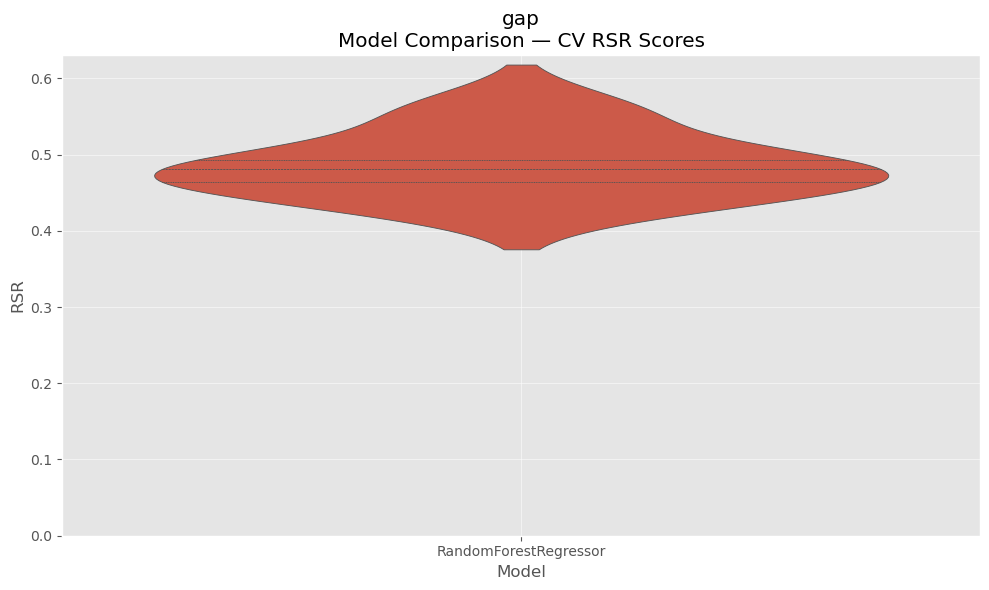

In [64]:
plot_violin(X_cv, y_train, models, metric='rsr')

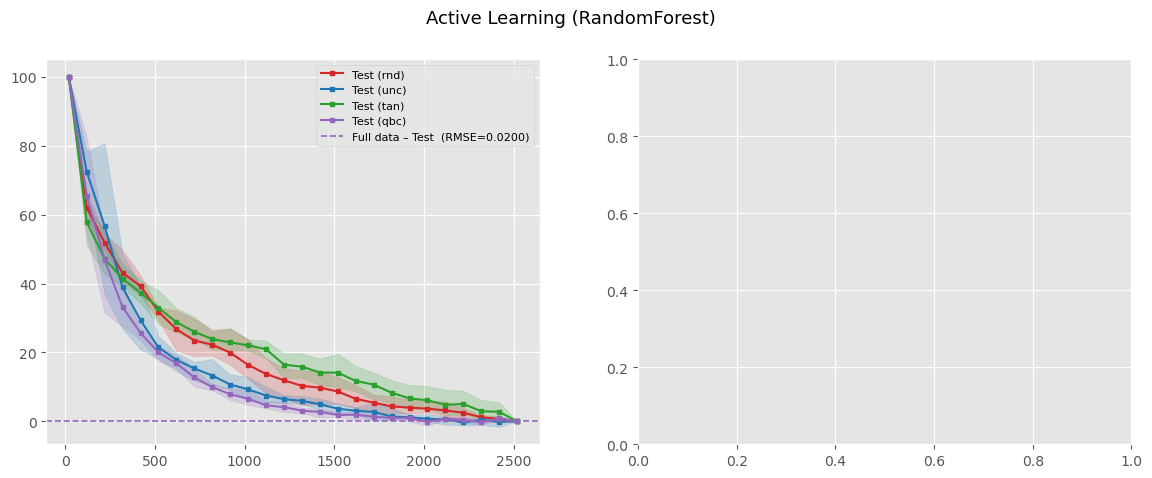

In [88]:
n = np.array(history_rnd[0]['history']['n_labeled'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Active Learning (RandomForest)', fontsize=13)

# --- RMSE ---
ax = axes[0]

y_rnd = np.array([run['history']['test_rmse'] for run in history_rnd], dtype=float)
start = y_rnd[:, [0]]
end = y_rnd[:, [-1]]
y_rnd_scaled = 100 * (y_rnd - end) / (start - end)

ax.plot(
    n,
    y_rnd_scaled.mean(axis=0),
    's-',
    ms=3,
    lw=1.5,
    label='Test (rnd)',
    color='tab:red',
)
ax.fill_between(
    n,
    y_rnd_scaled.min(axis=0),
    y_rnd_scaled.max(axis=0),
    color='tab:red',
    alpha=0.2,
)

y_unc = np.array([run['history']['test_rmse'] for run in history_unc], dtype=float)
start = y_unc[:, [0]]
end = y_unc[:, [-1]]
y_unc_scaled = 100 * (y_unc - end) / (start - end)

ax.plot(
    n,
    y_unc_scaled.mean(axis=0),
    's-',
    ms=3,
    lw=1.5,
    label='Test (unc)',
    color='tab:blue',
)
ax.fill_between(
    n,
    y_unc_scaled.min(axis=0),
    y_unc_scaled.max(axis=0),
    color='tab:blue',
    alpha=0.2,
)

y_tan = np.array([run['history']['test_rmse'] for run in history_tan], dtype=float)
start = y_tan[:, [0]]
end = y_tan[:, [-1]]
y_tan_scaled = 100 * (y_tan - end) / (start - end)

ax.plot(
    n,
    y_tan_scaled.mean(axis=0),
    's-',
    ms=3,
    lw=1.5,
    label='Test (tan)',
    color='tab:green',
)
ax.fill_between(
    n,
    y_tan_scaled.min(axis=0),
    y_tan_scaled.max(axis=0),
    color='tab:green',
    alpha=0.2,
)

y_qbc = np.array([run['history']['test_rmse'] for run in history_qbc], dtype=float)
start = y_qbc[:, [0]]
end = y_qbc[:, [-1]]
denom = start - end

y_qbc_scaled = 100 * (y_qbc - end) / denom

y_mean = y_qbc_scaled.mean(axis=0)
y_min = y_qbc_scaled.min(axis=0)
y_max = y_qbc_scaled.max(axis=0)

ax.plot(n, y_mean,  's-',  ms=3, lw=1.5, label='Test (qbc)', color='tab:purple', )
ax.fill_between(n, y_min, y_max, color='tab:purple', alpha=0.2,)

ax.axhline(0, color='tab:purple', ls='--', lw=1.2,
           label=f'Full data – Test  (RMSE={committee_score['test_rmse']:.4f})')

ax.legend(fontsize=8)